# Práctica 3: A*, Hill Climbing y optimización de redes

**Curso:** CC3074 - Modelización y Simulación  
**Universidad del Valle de Guatemala - 2026**

## Objetivo y forma de trabajo

Este notebook resuelve los tres problemas de la guía sin utilizar funciones que implementen directamente los algoritmos. Cada solución separa con claridad:

1. **Entradas:** datos del problema y estructuras que los representan.
2. **Proceso:** algoritmo reutilizable y registro de sus iteraciones.
3. **Resultado:** solución, validaciones, gráfica e interpretación.

Se usan únicamente módulos de la biblioteca estándar y `matplotlib`. Las semillas se fijan para que los resultados sean reproducibles.

In [1]:
from collections import deque
from itertools import permutations
import heapq
import math
import random

import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 5.5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
})

---

# Parte 1. Hill Climbing - Problema del agente viajero

## 1.1 Entradas y representación

Una carretera se guarda en ambas direcciones porque la tabla describe conexiones de doble sentido. Un tour es una lista que comienza y termina en la ciudad 1. La función objetivo suma las distancias de cada par consecutivo; si falta una carretera, el valor es infinito (`math.inf`), de modo que el tour se reconoce como inválido y nunca puede ser elegido como mejora.

In [2]:
carreteras = [
    (1, 2, 12), (1, 3, 10), (1, 7, 12),
    (2, 3, 8), (2, 4, 12),
    (3, 4, 11), (3, 5, 3), (3, 7, 9),
    (4, 5, 11), (4, 6, 10),
    (5, 6, 6), (5, 7, 7),
    (6, 7, 9),
]

distancias = {}
for ciudad_a, ciudad_b, distancia in carreteras:
    distancias[(ciudad_a, ciudad_b)] = distancia
    distancias[(ciudad_b, ciudad_a)] = distancia


def distancia_tour(tour, distancias):
    '''Devuelve la distancia total; math.inf indica un tour inválido.'''
    if len(tour) < 2 or tour[0] != 1 or tour[-1] != 1:
        return math.inf
    if len(set(tour[:-1])) != len(tour) - 1:
        return math.inf

    total = 0
    for origen, destino in zip(tour, tour[1:]):
        if (origen, destino) not in distancias:
            return math.inf
        total += distancias[(origen, destino)]
    return total


tour_inicial = [1, 2, 3, 4, 5, 6, 7, 1]
distancia_inicial = distancia_tour(tour_inicial, distancias)

print("Tour inicial:", "-".join(map(str, tour_inicial)))
print("Distancia:", distancia_inicial)
print("¿Es válido?:", math.isfinite(distancia_inicial))

assert distancia_inicial == 69

Tour inicial: 1-2-3-4-5-6-7-1
Distancia: 69
¿Es válido?: True


El tour inicial es válido y mide **69 unidades**. La comprobación recorre sus siete carreteras; si una sola no existiera, el resultado sería infinito.

## 1.2 Vecindario por inversión de sub-recorridos

Los índices interiores del tour son las ciudades que se pueden reordenar. Para cada par de posiciones `i < j`, se invierte el tramo inclusivo `tour[i:j+1]`. Los extremos nunca se eligen, por lo que la ciudad 1 permanece fija. La función devuelve únicamente vecinos válidos junto con su distancia y el tramo invertido.

In [3]:
def vecinos(tour, distancias):
    '''Genera vecinos válidos invirtiendo un tramo de las ciudades interiores.'''
    resultado = []
    for i in range(1, len(tour) - 2):
        for j in range(i + 1, len(tour) - 1):
            candidato = tour[:i] + list(reversed(tour[i:j + 1])) + tour[j + 1:]
            distancia = distancia_tour(candidato, distancias)
            if math.isfinite(distancia):
                resultado.append((candidato, distancia, (i, j)))
    return resultado


vecinos_iniciales = vecinos(tour_inicial, distancias)
print(f"Vecinos válidos del tour inicial: {len(vecinos_iniciales)}")
for candidato, distancia, tramo in vecinos_iniciales:
    ciudades_invertidas = tour_inicial[tramo[0]:tramo[1] + 1]
    print(f"  tramo {tramo} {ciudades_invertidas} -> {candidato}, distancia={distancia}")

Vecinos válidos del tour inicial: 5
  tramo (1, 2) [2, 3] -> [1, 3, 2, 4, 5, 6, 7, 1], distancia=68
  tramo (1, 6) [2, 3, 4, 5, 6, 7] -> [1, 7, 6, 5, 4, 3, 2, 1], distancia=69
  tramo (2, 3) [3, 4] -> [1, 2, 4, 3, 5, 6, 7, 1], distancia=65
  tramo (3, 4) [4, 5] -> [1, 2, 3, 5, 4, 6, 7, 1], distancia=65
  tramo (4, 5) [5, 6] -> [1, 2, 3, 4, 6, 5, 7, 1], distancia=66


## 1.3 Hill Climbing de máximo descenso

En cada iteración se evalúan **todos** los vecinos válidos. El algoritmo elige el de menor distancia; esto es máximo descenso (o mejor mejora), no la primera mejora encontrada. Se detiene cuando el mejor vecino no reduce estrictamente la distancia actual.

In [4]:
def hill_climbing(tour_inicial, distancias, mostrar=True):
    '''Minimiza la distancia eligiendo en cada paso el mejor vecino válido.'''
    actual = list(tour_inicial)
    distancia_actual = distancia_tour(actual, distancias)
    if not math.isfinite(distancia_actual):
        raise ValueError("El tour inicial debe ser válido.")

    historial = []
    iteracion = 0
    while True:
        candidatos = vecinos(actual, distancias)
        if not candidatos:
            mejor_tour, mejor_distancia, tramo = None, math.inf, None
        else:
            mejor_tour, mejor_distancia, tramo = min(
                candidatos, key=lambda elemento: (elemento[1], elemento[0])
            )

        historial.append({
            "iteracion": iteracion,
            "tour_actual": actual.copy(),
            "distancia_actual": distancia_actual,
            "mejor_vecino": None if mejor_tour is None else mejor_tour.copy(),
            "distancia_vecino": mejor_distancia,
            "tramo": tramo,
        })

        if mostrar:
            vecino_texto = "ninguno" if mejor_tour is None else "-".join(map(str, mejor_tour))
            distancia_texto = "--" if not math.isfinite(mejor_distancia) else str(mejor_distancia)
            tramo_texto = "--" if tramo is None else f"{tramo}"
            print(
                f"iter={iteracion:>2} | actual={'-'.join(map(str, actual)):<15} "
                f"| d={distancia_actual:>2} | mejor={vecino_texto:<15} "
                f"| d_vecino={distancia_texto:>2} | tramo={tramo_texto}"
            )

        if mejor_tour is None or mejor_distancia >= distancia_actual:
            break

        actual = mejor_tour
        distancia_actual = mejor_distancia
        iteracion += 1

    return actual, distancia_actual, historial


mejor_desde_inicial, distancia_desde_inicial, historial_inicial = hill_climbing(
    tour_inicial, distancias
)

print("\nÓptimo local desde el tour inicial:", mejor_desde_inicial)
print("Distancia del óptimo local:", distancia_desde_inicial)

iter= 0 | actual=1-2-3-4-5-6-7-1 | d=69 | mejor=1-2-3-5-4-6-7-1 | d_vecino=65 | tramo=(3, 4)
iter= 1 | actual=1-2-3-5-4-6-7-1 | d=65 | mejor=1-7-6-4-5-3-2-1 | d_vecino=65 | tramo=(1, 6)

Óptimo local desde el tour inicial: [1, 2, 3, 5, 4, 6, 7, 1]
Distancia del óptimo local: 65


La última fila del registro es la condición de parada: muestra el mejor vecino disponible, pero su distancia ya no es menor que la actual. Por eso el algoritmo no debe moverse.

## 1.4 Variante con 100 reinicios aleatorios

Primero se enumeran los tours **válidos** para evitar iniciar el algoritmo en una solución imposible. Después se seleccionan 100 puntos de inicio con reemplazo usando una semilla fija. Cada reinicio ejecuta el mismo Hill Climbing, pero sin imprimir sus iteraciones para mantener legible la salida.

In [5]:
def tours_validos(ciudades, distancias):
    resultado = []
    for orden in permutations(ciudades):
        tour = [1, *orden, 1]
        distancia = distancia_tour(tour, distancias)
        if math.isfinite(distancia):
            resultado.append(tour)
    return resultado


def hill_climbing_reinicios(distancias, reinicios=100, semilla=3074):
    rng = random.Random(semilla)
    inicios = tours_validos([2, 3, 4, 5, 6, 7], distancias)
    if not inicios:
        raise ValueError("No existen tours válidos para reiniciar el algoritmo.")

    mejor_tour = None
    mejor_distancia = math.inf
    resultados = []
    for numero in range(1, reinicios + 1):
        inicio = list(rng.choice(inicios))
        tour, distancia, _ = hill_climbing(inicio, distancias, mostrar=False)
        resultados.append((numero, inicio, tour, distancia))
        if distancia < mejor_distancia or (
            distancia == mejor_distancia and (mejor_tour is None or tour < mejor_tour)
        ):
            mejor_tour, mejor_distancia = tour, distancia

    return mejor_tour, mejor_distancia, resultados, len(inicios)


mejor_hc, distancia_hc, resultados_reinicios, cantidad_validos = hill_climbing_reinicios(
    distancias, reinicios=100, semilla=3074
)

frecuencias = {}
for _, _, tour, distancia in resultados_reinicios:
    frecuencias[distancia] = frecuencias.get(distancia, 0) + 1

print("Tours iniciales válidos posibles:", cantidad_validos)
print("Reinicios ejecutados:", len(resultados_reinicios))
print("Mejor tour:", "-".join(map(str, mejor_hc)))
print("Mejor distancia:", distancia_hc)
print("Frecuencia de los óptimos locales finales:")
for distancia, frecuencia in sorted(frecuencias.items()):
    print(f"  distancia {distancia}: {frecuencia} reinicios")

# Validación independiente: el espacio solo tiene 6! permutaciones.
todos_validos = tours_validos([2, 3, 4, 5, 6, 7], distancias)
optimo_exhaustivo = min((distancia_tour(t, distancias), t) for t in todos_validos)
print("Validación exhaustiva (distancia, tour):", optimo_exhaustivo)
assert distancia_hc == optimo_exhaustivo[0]

Tours iniciales válidos posibles: 20
Reinicios ejecutados: 100
Mejor tour: 1-2-4-6-7-5-3-1
Mejor distancia: 63
Frecuencia de los óptimos locales finales:
  distancia 63: 33 reinicios
  distancia 64: 19 reinicios
  distancia 65: 48 reinicios
Validación exhaustiva (distancia, tour): (63, [1, 2, 4, 6, 7, 5, 3, 1])


## 1.5 Gráfica del mejor recorrido

Las líneas grises son carreteras disponibles; el recorrido encontrado se resalta en verde y sus pasos se numeran. La gráfica no altera el algoritmo: solo representa el resultado.

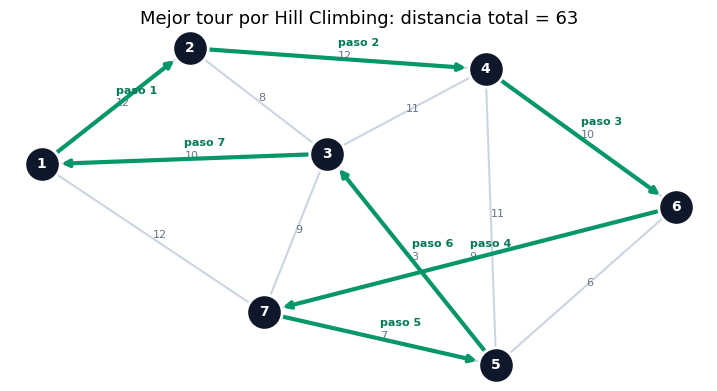

In [6]:
posiciones_ciudades = {
    1: (0.0, 1.4),
    2: (1.4, 2.5),
    3: (2.7, 1.5),
    4: (4.2, 2.3),
    5: (4.3, -0.5),
    6: (6.0, 1.0),
    7: (2.1, 0.0),
}


def graficar_tour(carreteras, posiciones, tour, distancia):
    fig, ax = plt.subplots(figsize=(9, 5.5))

    for a, b, peso in carreteras:
        xa, ya = posiciones[a]
        xb, yb = posiciones[b]
        ax.plot([xa, xb], [ya, yb], color="#cbd5e1", linewidth=1.5, zorder=1)
        ax.text((xa + xb) / 2, (ya + yb) / 2, str(peso), color="#64748b", fontsize=8)

    for paso, (a, b) in enumerate(zip(tour, tour[1:]), start=1):
        xa, ya = posiciones[a]
        xb, yb = posiciones[b]
        ax.annotate(
            "",
            xy=(xb, yb), xytext=(xa, ya),
            arrowprops=dict(arrowstyle="->", color="#059669", lw=3, shrinkA=14, shrinkB=14),
            zorder=3,
        )
        ax.text(
            (xa + xb) / 2, (ya + yb) / 2 + 0.12,
            f"paso {paso}", color="#047857", fontsize=8, fontweight="bold",
        )

    for ciudad, (x, y) in posiciones.items():
        ax.scatter(x, y, s=650, color="#0f172a", edgecolor="white", linewidth=2, zorder=4)
        ax.text(x, y, str(ciudad), color="white", ha="center", va="center", fontweight="bold", zorder=5)

    ax.set_title(f"Mejor tour por Hill Climbing: distancia total = {distancia}")
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()


graficar_tour(carreteras, posiciones_ciudades, mejor_hc, distancia_hc)

## Respuestas de análisis - Hill Climbing

**¿Qué representa una solución, un vecino y la función objetivo?**  
Una solución es un tour completo que sale de 1, visita exactamente una vez las ciudades 2 a 7 y regresa a 1 usando carreteras existentes. Un vecino es otro tour válido producido al invertir un sub-recorrido interior. La función objetivo es la suma de las distancias de sus carreteras y se desea minimizar.

**¿Por qué Hill Climbing puede detenerse aunque exista un recorrido mejor?**  
Solo compara la solución actual con vecinos alcanzables mediante una inversión. Si todos esos vecinos son iguales o peores, se detiene en un óptimo local. Alcanzar una región mejor podría exigir primero un movimiento que empeore temporalmente el objetivo; Hill Climbing no acepta ese paso.

**¿Qué efecto tuvieron los reinicios aleatorios?**  
Los reinicios cambiaron el punto de partida y permitieron explorar distintas cuencas de atracción. En esta ejecución reproducible, 33 reinicios terminaron con distancia 63, 19 con 64 y 48 con 65. El mejor resultado, **1-2-4-6-7-5-3-1 con distancia 63**, coincide con el óptimo verificado al enumerar los tours válidos. Esto no convierte a Hill Climbing en un método exacto en general, pero reduce la dependencia de un único inicio.

---

# Parte 2. A* - Ruta más corta en una red

## 2.1 Entradas y heurística

La red es de doble sentido. La heurística es la distancia euclidiana desde el nodo actual hasta `T`. En estos datos es una estimación informada y no sobrestima el costo de los caminos disponibles, por lo que A* conserva la optimalidad.

In [7]:
caminos = [
    ("O", "A", 2), ("O", "B", 5), ("O", "C", 4),
    ("A", "B", 2), ("A", "D", 7),
    ("B", "C", 1), ("B", "D", 4), ("B", "E", 3),
    ("C", "E", 4), ("D", "E", 1),
    ("D", "T", 5), ("E", "T", 7),
]

coordenadas = {
    "O": (0.0, 0.0), "A": (1.5, 1.2), "B": (2.5, 0.0),
    "C": (2.8, -0.8), "D": (5.5, 1.0), "E": (5.2, 0.2),
    "T": (9.0, 0.5),
}

grafo = {nodo: {} for nodo in coordenadas}
for origen, destino, costo in caminos:
    grafo[origen][destino] = costo
    grafo[destino][origen] = costo


def heuristica(nodo, meta, coordenadas):
    x1, y1 = coordenadas[nodo]
    x2, y2 = coordenadas[meta]
    return math.hypot(x2 - x1, y2 - y1)


print("Heurística euclidiana respecto de T:")
for nodo in coordenadas:
    print(f"  h({nodo}) = {heuristica(nodo, 'T', coordenadas):.3f}")

# Consistencia: para cada camino (u,v), h(u) <= costo(u,v) + h(v), y viceversa.
heuristica_consistente = all(
    heuristica(u, "T", coordenadas) <= peso + heuristica(v, "T", coordenadas) + 1e-12
    and heuristica(v, "T", coordenadas) <= peso + heuristica(u, "T", coordenadas) + 1e-12
    for u, v, peso in caminos
)
print("Heurística consistente en todas las aristas:", heuristica_consistente)
assert heuristica_consistente

Heurística euclidiana respecto de T:
  h(O) = 9.014
  h(A) = 7.533
  h(B) = 6.519
  h(C) = 6.335
  h(D) = 3.536
  h(E) = 3.812
  h(T) = 0.000
Heurística consistente en todas las aristas: True


## 2.2 Implementación de A* con `heapq`

La cola de prioridad guarda tuplas `(f, g, nodo)`. Al expandir un nodo, se relajan sus conexiones: si se descubre un `g` menor, se actualizan su costo y su predecesor. La lista abierta mostrada en cada fila contiene las mejores entradas pendientes después de procesar al nodo expandido.

In [8]:
def reconstruir_camino(predecesor, meta):
    camino = [meta]
    while camino[-1] in predecesor:
        camino.append(predecesor[camino[-1]])
    camino.reverse()
    return camino


def a_estrella(grafo, coordenadas, inicio, meta, usar_heuristica=True, mostrar=True):
    def h(nodo):
        return heuristica(nodo, meta, coordenadas) if usar_heuristica else 0.0

    mejor_g = {inicio: 0.0}
    predecesor = {}
    abierta = [(h(inicio), 0.0, inicio)]
    cerrada = set()
    registro = []

    while abierta:
        f_actual, g_actual, actual = heapq.heappop(abierta)
        if actual in cerrada or g_actual != mejor_g.get(actual):
            continue

        cerrada.add(actual)
        h_actual = h(actual)

        if actual != meta:
            for vecino, costo in sorted(grafo[actual].items()):
                tentativo = g_actual + costo
                if tentativo < mejor_g.get(vecino, math.inf):
                    mejor_g[vecino] = tentativo
                    predecesor[vecino] = actual
                    heapq.heappush(abierta, (tentativo + h(vecino), tentativo, vecino))

        mejores_abiertos = {}
        for f_pendiente, g_pendiente, nodo_pendiente in abierta:
            if nodo_pendiente in cerrada or g_pendiente != mejor_g.get(nodo_pendiente):
                continue
            if nodo_pendiente not in mejores_abiertos or f_pendiente < mejores_abiertos[nodo_pendiente][0]:
                mejores_abiertos[nodo_pendiente] = (f_pendiente, g_pendiente)

        contenido_abierta = sorted(
            [(nodo, fg[1], h(nodo), fg[0]) for nodo, fg in mejores_abiertos.items()],
            key=lambda x: (x[3], x[0]),
        )
        registro.append((actual, g_actual, h_actual, f_actual, contenido_abierta))

        if mostrar:
            abierta_texto = ", ".join(
                f"{nodo}(g={g:.1f},h={hv:.2f},f={f:.2f})"
                for nodo, g, hv, f in contenido_abierta
            ) or "vacía"
            print(
                f"expandido={actual} | g={g_actual:.1f} | h={h_actual:.3f} "
                f"| f={f_actual:.3f} | abierta=[{abierta_texto}]"
            )

        if actual == meta:
            return reconstruir_camino(predecesor, meta), g_actual, registro

    return None, math.inf, registro


ruta_a, costo_a, registro_a = a_estrella(grafo, coordenadas, "O", "T")
print("\nRuta final A*:", " -> ".join(ruta_a))
print("Costo total:", costo_a)
print("Nodos expandidos:", len(registro_a))
assert costo_a == 13

expandido=O | g=0.0 | h=9.014 | f=9.014 | abierta=[A(g=2.0,h=7.53,f=9.53), C(g=4.0,h=6.33,f=10.33), B(g=5.0,h=6.52,f=11.52)]
expandido=A | g=2.0 | h=7.533 | f=9.533 | abierta=[C(g=4.0,h=6.33,f=10.33), B(g=4.0,h=6.52,f=10.52), D(g=9.0,h=3.54,f=12.54)]
expandido=C | g=4.0 | h=6.335 | f=10.335 | abierta=[B(g=4.0,h=6.52,f=10.52), E(g=8.0,h=3.81,f=11.81), D(g=9.0,h=3.54,f=12.54)]
expandido=B | g=4.0 | h=6.519 | f=10.519 | abierta=[E(g=7.0,h=3.81,f=10.81), D(g=8.0,h=3.54,f=11.54)]
expandido=E | g=7.0 | h=3.812 | f=10.812 | abierta=[D(g=8.0,h=3.54,f=11.54), T(g=14.0,h=0.00,f=14.00)]
expandido=D | g=8.0 | h=3.536 | f=11.536 | abierta=[T(g=13.0,h=0.00,f=13.00)]
expandido=T | g=13.0 | h=0.000 | f=13.000 | abierta=[vacía]

Ruta final A*: O -> A -> B -> D -> T
Costo total: 13.0
Nodos expandidos: 7


## 2.3 Ejecución con `h(n)=0`: relación con Dijkstra

Al fijar la heurística en cero, `f(n)=g(n)`. La cola selecciona siempre el nodo con menor costo acumulado desde el origen, que es precisamente el criterio de Dijkstra para pesos no negativos.

In [9]:
ruta_dijkstra, costo_dijkstra, registro_dijkstra = a_estrella(
    grafo, coordenadas, "O", "T", usar_heuristica=False
)

print("\nRuta con h(n)=0:", " -> ".join(ruta_dijkstra))
print("Costo total:", costo_dijkstra)
print("Nodos expandidos:", len(registro_dijkstra))
print("Mismo costo óptimo que A*:", costo_dijkstra == costo_a)

assert costo_dijkstra == costo_a == 13

expandido=O | g=0.0 | h=0.000 | f=0.000 | abierta=[A(g=2.0,h=0.00,f=2.00), C(g=4.0,h=0.00,f=4.00), B(g=5.0,h=0.00,f=5.00)]
expandido=A | g=2.0 | h=0.000 | f=2.000 | abierta=[B(g=4.0,h=0.00,f=4.00), C(g=4.0,h=0.00,f=4.00), D(g=9.0,h=0.00,f=9.00)]
expandido=B | g=4.0 | h=0.000 | f=4.000 | abierta=[C(g=4.0,h=0.00,f=4.00), E(g=7.0,h=0.00,f=7.00), D(g=8.0,h=0.00,f=8.00)]
expandido=C | g=4.0 | h=0.000 | f=4.000 | abierta=[E(g=7.0,h=0.00,f=7.00), D(g=8.0,h=0.00,f=8.00)]
expandido=E | g=7.0 | h=0.000 | f=7.000 | abierta=[D(g=8.0,h=0.00,f=8.00), T(g=14.0,h=0.00,f=14.00)]
expandido=D | g=8.0 | h=0.000 | f=8.000 | abierta=[T(g=13.0,h=0.00,f=13.00)]
expandido=T | g=13.0 | h=0.000 | f=13.000 | abierta=[vacía]

Ruta con h(n)=0: O -> A -> B -> D -> T
Costo total: 13.0
Nodos expandidos: 7
Mismo costo óptimo que A*: True


Ambos métodos obtienen costo mínimo **13**. Puede haber más de una ruta con ese costo; que se muestre una u otra depende del desempate de la cola, no de una pérdida de optimalidad. En esta red pequeña ambos expanden los 7 nodos: la heurística sí cambia el orden y las prioridades, pero no alcanza a evitar una expansión antes de confirmar la meta. Una heurística útil **puede** reducir expansiones, aunque no tiene que hacerlo en toda instancia.

## 2.4 Gráfica de la red y la ruta encontrada

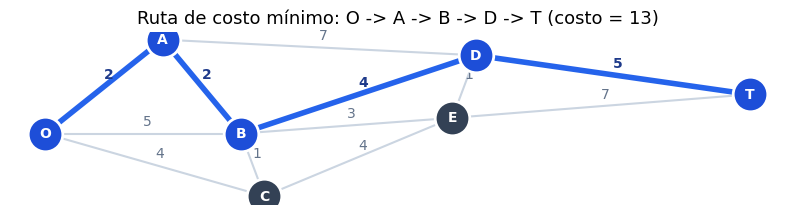

In [10]:
def graficar_ruta(caminos, coordenadas, ruta, costo_total):
    fig, ax = plt.subplots(figsize=(10, 5))
    aristas_ruta = {frozenset((a, b)) for a, b in zip(ruta, ruta[1:])}

    for a, b, peso in caminos:
        xa, ya = coordenadas[a]
        xb, yb = coordenadas[b]
        resaltada = frozenset((a, b)) in aristas_ruta
        ax.plot(
            [xa, xb], [ya, yb],
            color="#2563eb" if resaltada else "#cbd5e1",
            linewidth=4 if resaltada else 1.5,
            zorder=2 if resaltada else 1,
        )
        ax.text(
            (xa + xb) / 2, (ya + yb) / 2 + 0.10,
            str(peso), color="#1e3a8a" if resaltada else "#64748b",
            fontweight="bold" if resaltada else "normal",
        )

    for nodo, (x, y) in coordenadas.items():
        en_ruta = nodo in ruta
        ax.scatter(
            x, y, s=620,
            color="#1d4ed8" if en_ruta else "#334155",
            edgecolor="white", linewidth=2, zorder=3,
        )
        ax.text(x, y, nodo, color="white", ha="center", va="center", fontweight="bold", zorder=4)

    ax.set_title(f"Ruta de costo mínimo: {' -> '.join(ruta)} (costo = {costo_total:g})")
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()


graficar_ruta(caminos, coordenadas, ruta_a, costo_a)

## Respuestas de análisis - A*

**¿Qué información aportan `g(n)` y `h(n)`?**  
`g(n)` es el costo exacto del mejor camino conocido desde `O` hasta `n`; resume lo que ya se pagó. `h(n)` estima el costo que falta desde `n` hasta `T`; orienta la búsqueda hacia la meta. Su suma `f(n)` estima el costo total de una solución que pasa por `n`.

**¿Por qué una heurística útil puede reducir los nodos explorados?**  
Porque diferencia nodos que tienen costos acumulados parecidos pero distintas perspectivas de llegar a la meta. Una heurística informativa da prioridad a los que parecen completar una ruta barata y evita expandir temprano regiones poco prometedoras. Para garantizar el óptimo no debe sobreestimar el costo restante.

**¿Qué ocurre conceptualmente cuando `h(n)=0`?**  
Desaparece la información sobre la ubicación de la meta y queda `f(n)=g(n)`. A* se convierte en Dijkstra: explora la red en orden de distancia acumulada desde el origen. Conserva el costo óptimo con pesos no negativos, aunque puede expandir más nodos.

---

# Parte 3. Flujo máximo y costo mínimo - Distribución de suministros

## 3.1 Datos de la red dirigida

Cada clave `(origen, destino)` representa un tramo dirigido. Se separan capacidad y costo unitario porque responden preguntas distintas: la capacidad limita cuánto puede pasar y el costo mide cuánto cuesta usar una unidad del tramo.

In [11]:
datos_red = [
    ("S", "A", 5, 2), ("S", "B", 7, 1), ("S", "C", 4, 3),
    ("A", "B", 1, 1), ("A", "D", 3, 2),
    ("B", "C", 2, 1), ("B", "D", 4, 3), ("B", "E", 5, 2),
    ("C", "E", 4, 1),
    ("D", "T", 9, 2),
    ("E", "D", 1, 1), ("E", "T", 6, 3),
]

capacidades = {(u, v): capacidad for u, v, capacidad, _ in datos_red}
costos = {(u, v): costo for u, v, _, costo in datos_red}

print("Tramo | capacidad | costo/unidad")
for u, v, capacidad, costo in datos_red:
    print(f"{u:>1} -> {v:<1} | {capacidad:^9} | {costo:^12}")

Tramo | capacidad | costo/unidad
S -> A |     5     |      2      
S -> B |     7     |      1      
S -> C |     4     |      3      
A -> B |     1     |      1      
A -> D |     3     |      2      
B -> C |     2     |      1      
B -> D |     4     |      3      
B -> E |     5     |      2      
C -> E |     4     |      1      
D -> T |     9     |      2      
E -> D |     1     |      1      
E -> T |     6     |      3      


## Parte A. Flujo máximo con Edmonds-Karp

### 3.2 Red residual y BFS

Para cada tramo original se crea una arista residual hacia adelante con su capacidad y una arista de regreso con capacidad inicial cero. BFS guarda predecesores y reconstruye un camino aumentante cuando alcanza `T`. Edmonds-Karp repite el proceso, envía el cuello de botella y actualiza ambas direcciones residuales.

In [12]:
def construir_residual(capacidades):
    residual = {}
    for (u, v), capacidad in capacidades.items():
        residual.setdefault(u, {})[v] = capacidad
        residual.setdefault(v, {}).setdefault(u, 0)
    return residual


def bfs_camino(residual, fuente, destino):
    '''Encuentra con BFS un camino que solo usa capacidad residual positiva.'''
    cola = deque([fuente])
    padre = {fuente: None}

    while cola:
        u = cola.popleft()
        for v in sorted(residual.get(u, {})):
            if residual[u][v] > 0 and v not in padre:
                padre[v] = u
                if v == destino:
                    camino = [destino]
                    while camino[-1] != fuente:
                        camino.append(padre[camino[-1]])
                    camino.reverse()
                    return camino
                cola.append(v)
    return None


def edmonds_karp(capacidades, fuente, destino, mostrar=True):
    residual = construir_residual(capacidades)
    flujos = {arista: 0 for arista in capacidades}
    flujo_total = 0
    historial = []
    iteracion = 1

    while True:
        camino = bfs_camino(residual, fuente, destino)
        if camino is None:
            break

        cuello = min(residual[u][v] for u, v in zip(camino, camino[1:]))
        for u, v in zip(camino, camino[1:]):
            residual[u][v] -= cuello
            residual[v][u] += cuello
            if (u, v) in flujos:
                flujos[(u, v)] += cuello
            else:
                flujos[(v, u)] -= cuello

        flujo_total += cuello
        historial.append((camino, cuello, cuello, flujo_total))
        if mostrar:
            print(
                f"iter={iteracion:>2} | camino={' -> '.join(camino):<25} "
                f"| cuello={cuello} | enviado={cuello} | acumulado={flujo_total}"
            )
        iteracion += 1

    return flujo_total, flujos, residual, historial


flujo_maximo, flujo_edmonds_karp, residual_maximo, historial_flujo = edmonds_karp(
    capacidades, "S", "T"
)

print("\nFlujo máximo:", flujo_maximo)
print("Flujo utilizado en cada tramo:")
for (u, v), capacidad in capacidades.items():
    print(f"  {u} -> {v}: {flujo_edmonds_karp[(u, v)]}/{capacidad}")

iter= 1 | camino=S -> A -> D -> T          | cuello=3 | enviado=3 | acumulado=3
iter= 2 | camino=S -> B -> D -> T          | cuello=4 | enviado=4 | acumulado=7
iter= 3 | camino=S -> B -> E -> T          | cuello=3 | enviado=3 | acumulado=10
iter= 4 | camino=S -> C -> E -> T          | cuello=3 | enviado=3 | acumulado=13
iter= 5 | camino=S -> C -> E -> D -> T     | cuello=1 | enviado=1 | acumulado=14

Flujo máximo: 14
Flujo utilizado en cada tramo:
  S -> A: 3/5
  S -> B: 7/7
  S -> C: 4/4
  A -> B: 0/1
  A -> D: 3/3
  B -> C: 0/2
  B -> D: 4/4
  B -> E: 3/5
  C -> E: 4/4
  D -> T: 8/9
  E -> D: 1/1
  E -> T: 6/6


### 3.3 Verificación de capacidad y conservación

Las dos condiciones se comprueban por código, no solo visualmente:

- En cada tramo: `0 <= flujo <= capacidad`.
- En cada nodo intermedio: suma de entradas = suma de salidas.

En `S` la diferencia salida-entrada debe ser el flujo máximo; en `T`, entrada-salida debe ser el mismo valor.

In [13]:
def verificar_flujo(capacidades, flujos, fuente, destino, flujo_esperado):
    nodos = sorted({n for arista in capacidades for n in arista})
    capacidad_valida = all(
        0 <= flujos[arista] <= capacidad for arista, capacidad in capacidades.items()
    )

    balances = {}
    for nodo in nodos:
        entrada = sum(flujo for (u, v), flujo in flujos.items() if v == nodo)
        salida = sum(flujo for (u, v), flujo in flujos.items() if u == nodo)
        balances[nodo] = (entrada, salida, entrada - salida)

    conservacion_valida = all(
        balances[nodo][0] == balances[nodo][1]
        for nodo in nodos if nodo not in (fuente, destino)
    )
    extremos_validos = (
        balances[fuente][1] - balances[fuente][0] == flujo_esperado
        and balances[destino][0] - balances[destino][1] == flujo_esperado
    )

    print("Capacidades respetadas:", capacidad_valida)
    print("Conservación en nodos intermedios:", conservacion_valida)
    print("Balance correcto en fuente y destino:", extremos_validos)
    print("\nNodo | entrada | salida | entrada-salida")
    for nodo in nodos:
        entrada, salida, balance = balances[nodo]
        print(f"  {nodo}  | {entrada:^7} | {salida:^6} | {balance:^14}")

    return capacidad_valida and conservacion_valida and extremos_validos, balances


flujo_valido, balances_maximo = verificar_flujo(
    capacidades, flujo_edmonds_karp, "S", "T", flujo_maximo
)
assert flujo_valido
assert flujo_maximo == 14

Capacidades respetadas: True
Conservación en nodos intermedios: True
Balance correcto en fuente y destino: True

Nodo | entrada | salida | entrada-salida
  A  |    3    |   3    |       0       
  B  |    7    |   7    |       0       
  C  |    4    |   4    |       0       
  D  |    8    |   8    |       0       
  E  |    7    |   7    |       0       
  S  |    0    |   14   |      -14      
  T  |   14    |   0    |       14      


## Parte B. Flujo de costo mínimo

### 3.4 Residual con costos opuestos

La arista residual de regreso tiene costo negativo porque deshacer una unidad recupera el costo que se había agregado. Como pueden existir costos negativos residuales, el camino más barato se calcula con relajaciones de **Bellman-Ford**, implementadas aquí sin librerías externas. Así se evitan los supuestos de Dijkstra sobre pesos no negativos.

In [14]:
def construir_residual_costos(capacidades, costos):
    residual = construir_residual(capacidades)
    costos_residuales = {}
    for (u, v), costo in costos.items():
        costos_residuales[(u, v)] = costo
        costos_residuales[(v, u)] = -costo
    return residual, costos_residuales


def camino_menor_costo(residual, costos_residuales, fuente, destino):
    '''Bellman-Ford sobre aristas con capacidad residual positiva.'''
    nodos = sorted(residual)
    distancia = {nodo: math.inf for nodo in nodos}
    padre = {}
    distancia[fuente] = 0

    aristas = [
        (u, v, costos_residuales[(u, v)])
        for u in nodos
        for v, capacidad in residual[u].items()
        if capacidad > 0
    ]

    for _ in range(len(nodos) - 1):
        cambio = False
        for u, v, costo in aristas:
            if distancia[u] != math.inf and distancia[u] + costo < distancia[v]:
                distancia[v] = distancia[u] + costo
                padre[v] = u
                cambio = True
        if not cambio:
            break

    if distancia[destino] == math.inf:
        return None, math.inf

    camino = [destino]
    while camino[-1] != fuente:
        if camino[-1] not in padre:
            return None, math.inf
        camino.append(padre[camino[-1]])
    camino.reverse()
    return camino, distancia[destino]


def flujo_costo_minimo(capacidades, costos, fuente, destino, flujo_objetivo, mostrar=True):
    residual, costos_residuales = construir_residual_costos(capacidades, costos)
    flujos = {arista: 0 for arista in capacidades}
    flujo_total = 0
    costo_total = 0
    historial = []
    iteracion = 1

    while flujo_total < flujo_objetivo:
        camino, costo_unitario = camino_menor_costo(
            residual, costos_residuales, fuente, destino
        )
        if camino is None:
            raise ValueError("No existe capacidad suficiente para alcanzar el flujo objetivo.")

        cuello = min(residual[u][v] for u, v in zip(camino, camino[1:]))
        enviado = min(cuello, flujo_objetivo - flujo_total)

        for u, v in zip(camino, camino[1:]):
            residual[u][v] -= enviado
            residual[v][u] += enviado
            if (u, v) in flujos:
                flujos[(u, v)] += enviado
            else:
                flujos[(v, u)] -= enviado

        flujo_total += enviado
        costo_total += enviado * costo_unitario
        historial.append((camino, costo_unitario, cuello, enviado, flujo_total, costo_total))

        if mostrar:
            print(
                f"iter={iteracion:>2} | ruta={' -> '.join(camino):<27} "
                f"| costo/u={costo_unitario:>2} | cuello={cuello} "
                f"| enviado={enviado} | costo acum.={costo_total}"
            )
        iteracion += 1

    return flujo_total, costo_total, flujos, residual, historial


flujo_min_costo, costo_minimo, flujos_min_costo, residual_costo, historial_costo = (
    flujo_costo_minimo(capacidades, costos, "S", "T", flujo_maximo)
)

print("\nFlujo enviado:", flujo_min_costo)
print("Costo total mínimo:", costo_minimo)
print("Flujo utilizado en cada tramo:")
for (u, v), capacidad in capacidades.items():
    flujo = flujos_min_costo[(u, v)]
    print(f"  {u} -> {v}: flujo={flujo}/{capacidad}, costo/u={costos[(u, v)]}")

iter= 1 | ruta=S -> A -> D -> T            | costo/u= 6 | cuello=3 | enviado=3 | costo acum.=18
iter= 2 | ruta=S -> B -> D -> T            | costo/u= 6 | cuello=4 | enviado=4 | costo acum.=42
iter= 3 | ruta=S -> B -> E -> T            | costo/u= 6 | cuello=3 | enviado=3 | costo acum.=60
iter= 4 | ruta=S -> C -> E -> T            | costo/u= 7 | cuello=3 | enviado=3 | costo acum.=81
iter= 5 | ruta=S -> C -> E -> D -> T       | costo/u= 7 | cuello=1 | enviado=1 | costo acum.=88

Flujo enviado: 14
Costo total mínimo: 88
Flujo utilizado en cada tramo:
  S -> A: flujo=3/5, costo/u=2
  S -> B: flujo=7/7, costo/u=1
  S -> C: flujo=4/4, costo/u=3
  A -> B: flujo=0/1, costo/u=1
  A -> D: flujo=3/3, costo/u=2
  B -> C: flujo=0/2, costo/u=1
  B -> D: flujo=4/4, costo/u=3
  B -> E: flujo=3/5, costo/u=2
  C -> E: flujo=4/4, costo/u=1
  D -> T: flujo=8/9, costo/u=2
  E -> D: flujo=1/1, costo/u=1
  E -> T: flujo=6/6, costo/u=3


### 3.5 Validación del resultado de costo mínimo

Se reutilizan las restricciones de capacidad y conservación. Además, el costo se recalcula directamente como la suma `flujo_del_tramo * costo_unitario`; debe coincidir con el costo acumulado por los caminos residuales.

In [15]:
costo_recalculado = sum(
    flujos_min_costo[arista] * costos[arista] for arista in capacidades
)

flujo_costo_valido, balances_costo = verificar_flujo(
    capacidades, flujos_min_costo, "S", "T", flujo_min_costo
)

print("\nCosto acumulado por el algoritmo:", costo_minimo)
print("Costo recalculado desde los tramos:", costo_recalculado)
print("Coinciden:", costo_minimo == costo_recalculado)

assert flujo_costo_valido
assert flujo_min_costo == flujo_maximo == 14
assert costo_minimo == costo_recalculado

Capacidades respetadas: True
Conservación en nodos intermedios: True
Balance correcto en fuente y destino: True

Nodo | entrada | salida | entrada-salida
  A  |    3    |   3    |       0       
  B  |    7    |   7    |       0       
  C  |    4    |   4    |       0       
  D  |    8    |   8    |       0       
  E  |    7    |   7    |       0       
  S  |    0    |   14   |      -14      
  T  |   14    |   0    |       14      

Costo acumulado por el algoritmo: 88
Costo recalculado desde los tramos: 88
Coinciden: True


El resultado validado envía las **14 unidades** del flujo máximo con costo total mínimo **88**. La distribución satura `S -> B`, `S -> C`, `A -> D`, `B -> D`, `C -> E`, `E -> D` y `E -> T`; las comprobaciones anteriores confirman capacidad, conservación y costo.

## 3.6 Gráfica de la distribución de costo mínimo

La etiqueta de cada tramo tiene el formato **flujo/capacidad; costo unitario**. El grosor y color representan cuánto se utiliza proporcionalmente la conexión.

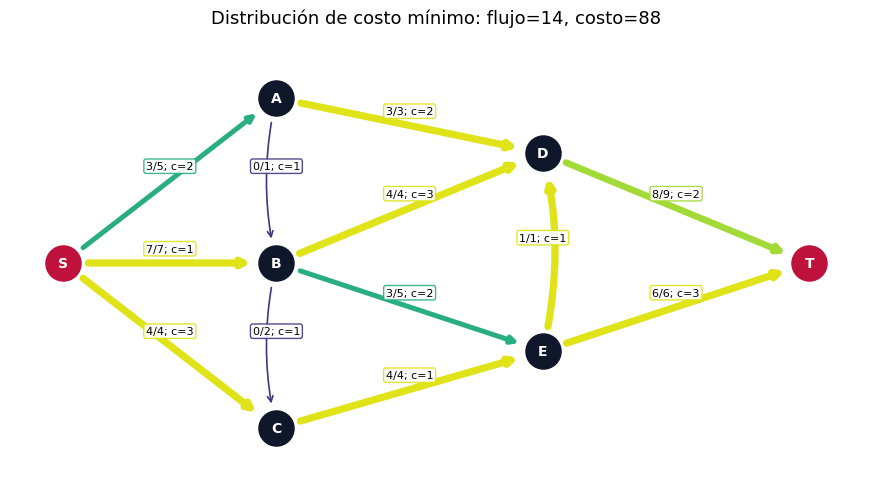

In [16]:
posiciones_red = {
    "S": (0.0, 1.5),
    "A": (2.0, 3.0), "B": (2.0, 1.5), "C": (2.0, 0.0),
    "D": (4.5, 2.5), "E": (4.5, 0.7),
    "T": (7.0, 1.5),
}


def graficar_flujo(datos_red, posiciones, flujos, flujo_total, costo_total):
    fig, ax = plt.subplots(figsize=(11, 6))

    for u, v, capacidad, costo in datos_red:
        flujo = flujos[(u, v)]
        x1, y1 = posiciones[u]
        x2, y2 = posiciones[v]
        uso = flujo / capacidad
        color = plt.cm.viridis(0.15 + 0.8 * uso)
        grosor = 1.2 + 4 * uso
        curvatura = 0.12 if (u, v) in {("A", "B"), ("B", "C"), ("E", "D")} else 0.0
        ax.annotate(
            "",
            xy=(x2, y2), xytext=(x1, y1),
            arrowprops=dict(
                arrowstyle="->", color=color, lw=grosor,
                shrinkA=18, shrinkB=18,
                connectionstyle=f"arc3,rad={curvatura}",
            ),
            zorder=2,
        )
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(
            mx, my + 0.13,
            f"{flujo}/{capacidad}; c={costo}",
            fontsize=8, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.9),
            zorder=4,
        )

    for nodo, (x, y) in posiciones.items():
        color = "#be123c" if nodo in {"S", "T"} else "#0f172a"
        ax.scatter(x, y, s=800, color=color, edgecolor="white", linewidth=2, zorder=5)
        ax.text(x, y, nodo, color="white", ha="center", va="center", fontweight="bold", zorder=6)

    ax.set_title(f"Distribución de costo mínimo: flujo={flujo_total}, costo={costo_total}")
    ax.set_xlim(-0.5, 7.5)
    ax.set_ylim(-0.6, 3.6)
    ax.axis("off")
    plt.show()


graficar_flujo(datos_red, posiciones_red, flujos_min_costo, flujo_min_costo, costo_minimo)

## Respuestas de análisis - Flujo y costo

**¿Por qué maximizar el flujo y minimizar el costo son objetivos distintos?**  
El flujo máximo pregunta por la mayor cantidad físicamente transportable y solo necesita capacidades. El costo mínimo pregunta cómo repartir una cantidad ya fijada para pagar lo menos posible. Primero se obtiene el valor máximo factible; después se optimiza la distribución de ese mismo valor.

**¿Puede haber dos distribuciones con el mismo flujo máximo pero costos diferentes?**  
Sí. Distintos caminos pueden llevar la misma cantidad a `T`, pero atravesar tramos con costos unitarios diferentes. Edmonds-Karp garantiza el valor del flujo, no su precio; por eso se requiere una segunda optimización.

**¿Para qué sirven las aristas de regreso?**  
Permiten corregir decisiones anteriores. En flujo máximo devuelven capacidad si una ruta posterior necesita reorganizar el flujo. En costo mínimo también llevan el costo opuesto, de modo que deshacer una unidad resta exactamente el costo que se había agregado.

**¿Qué conexión parece actuar como cuello de botella?**  
No hay un único tramo que explique por sí solo toda la cota. En el resultado, `E -> T` queda saturado y la salida alternativa `E -> D` solo permite 1 unidad, por lo que las salidas de `E` son una restricción visible. Globalmente, el corte formado por `A -> D`, `B -> D`, `E -> D` y `E -> T` suma 14 unidades; esa capacidad conjunta certifica el flujo máximo de 14.

---

# Integración final

| Algoritmo | Pregunta principal | Información utilizada | Resultado |
|---|---|---|---|
| Hill Climbing | ¿Cómo mejoro la solución actual? | Vecinos + función objetivo | Mejor solución local encontrada |
| A* | ¿Cuál es una ruta de menor costo? | `g(n) + h(n)` | Camino y costo |
| Flujo Máximo | ¿Cuánto puedo transportar? | Capacidades + red residual | Flujo máximo |
| Costo Mínimo | ¿Cómo transporto con menor costo? | Capacidad + flujo + costo | Distribución y costo total |

## Conclusión

Los cuatro métodos no son intercambiables porque contestan preguntas distintas. **Hill Climbing** mejora localmente una solución completa y es rápido, pero depende del punto inicial; los reinicios disminuyen ese riesgo. **A*** construye una ruta óptima y combina costo conocido con una estimación del costo restante; al anular la heurística se obtiene el comportamiento de Dijkstra. **Edmonds-Karp** usa la red residual para encontrar cuánto puede enviarse sin violar capacidades. Finalmente, el **flujo de costo mínimo** mantiene ese volumen máximo y usa costos residuales, incluidas aristas de regreso, para elegir la distribución más económica.

La idea común es que la representación determina qué decisiones puede corregir cada algoritmo: inversiones para Hill Climbing, predecesores y cola de prioridad para A*, y aristas residuales para flujo. Las validaciones incluidas comprueban que los resultados no solo se imprimen, sino que satisfacen formalmente las restricciones del problema.